# Лабораторная работа 5: Random Forest (career-con-2019)

**Условия выполнения:**
- Без `scikit-learn`, `pytorch`, `tensorflow`, `keras`.
- Разрешены вспомогательные библиотеки: `pandas`, `numpy`, `matplotlib`.

**Задание:**
- Использовать датасет `career-con-2019`.
- Обучить Random Forest (реализация с нуля).
- Обосновать ограничение глубины дерева.
- Посчитать `accuracy`, `precision`, `recall`, `F1`.
- Вывести ROC-кривую.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

np.random.seed(42)

## 1) Загрузка данных

В датасете каждый объект `series_id` состоит из 128 измерений сенсоров.
Для классификации поверхности агрегируем временной ряд в табличные признаки.

In [2]:
base_dir = Path('career-con-2019')
X_train_path = base_dir / 'X_train.csv'
y_train_path = base_dir / 'y_train.csv'

if not X_train_path.exists() or not y_train_path.exists():
    raise FileNotFoundError('Не найдены career-con-2019/X_train.csv и/или y_train.csv')

X_raw = pd.read_csv(X_train_path)
y_raw = pd.read_csv(y_train_path)

print('X_raw shape:', X_raw.shape)
print('y_raw shape:', y_raw.shape)
print('Число классов:', y_raw['surface'].nunique())
y_raw['surface'].value_counts()

X_raw shape: (487680, 13)
y_raw shape: (3810, 3)
Число классов: 9


surface
concrete                  779
soft_pvc                  732
wood                      607
tiled                     514
fine_concrete             363
hard_tiles_large_space    308
soft_tiles                297
carpet                    189
hard_tiles                 21
Name: count, dtype: int64

## 2) Подготовка признаков

Исключаем служебные поля и агрегируем признаки по `series_id`: `mean`, `std`, `min`, `max`, `median`, `q25`, `q75`.

In [3]:
drop_cols = ['row_id', 'measurement_number']
sensor_cols = [c for c in X_raw.columns if c not in drop_cols + ['series_id']]

grouped = X_raw.groupby('series_id')[sensor_cols]
X_stat = grouped.agg(['mean', 'std', 'min', 'max', 'median'])
q25 = grouped.quantile(0.25).add_suffix('_q25')
q75 = grouped.quantile(0.75).add_suffix('_q75')

X_stat.columns = [f'{c[0]}_{c[1]}' for c in X_stat.columns]
X_feat = X_stat.join(q25).join(q75).fillna(0.0)

y_series = y_raw[['series_id', 'surface']].set_index('series_id').loc[X_feat.index, 'surface']

classes = sorted(y_series.unique())
cls_to_id = {c: i for i, c in enumerate(classes)}
id_to_cls = {i: c for c, i in cls_to_id.items()}

X = X_feat.to_numpy(dtype=float)
y = np.array([cls_to_id[v] for v in y_series.to_numpy()])

print('Матрица признаков:', X.shape)
print('Классы:', classes)

Матрица признаков: (3810, 70)
Классы: ['carpet', 'concrete', 'fine_concrete', 'hard_tiles', 'hard_tiles_large_space', 'soft_pvc', 'soft_tiles', 'tiled', 'wood']


## 3) Реализация Decision Tree и Random Forest с нуля

Требование: дерево в Random Forest обычно **не бинарно-сбалансированное по форме**,
но алгоритмически каждый сплит делит множество на 2 подмножества (`<= threshold` и `> threshold`).
Такое дерево почти всегда несбалансировано по глубине разных ветвей.

Ограничение `max_depth` обязательно:
- без него деревья в ансамбле легко переобучаются на шум;
- в задаче много агрегированных признаков при сравнительно небольшом числе объектов;
- ограниченная глубина работает как регуляризация и улучшает обобщение.

In [4]:
def train_valid_split(X, y, test_size=0.2, random_state=42):
    rng = np.random.default_rng(random_state)
    train_idx = []
    valid_idx = []

    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        rng.shuffle(idx)
        n_valid = max(1, int(round(len(idx) * test_size)))
        valid_idx.extend(idx[:n_valid])
        train_idx.extend(idx[n_valid:])

    train_idx = np.array(train_idx, dtype=int)
    valid_idx = np.array(valid_idx, dtype=int)
    rng.shuffle(train_idx)
    rng.shuffle(valid_idx)

    return X[train_idx], X[valid_idx], y[train_idx], y[valid_idx]


def gini_impurity(y):
    if len(y) == 0:
        return 0.0
    counts = np.bincount(y)
    probs = counts[counts > 0] / len(y)
    return 1.0 - np.sum(probs ** 2)


def best_split_gini(X, y, feature_indices, min_samples_leaf):
    n = len(y)
    if n < 2 * min_samples_leaf:
        return None

    base_gini = gini_impurity(y)
    best = None

    for f in feature_indices:
        x = X[:, f]
        order = np.argsort(x)
        x_sorted = x[order]
        y_sorted = y[order]

        for i in range(min_samples_leaf, n - min_samples_leaf + 1):
            if i >= n:
                continue
            if x_sorted[i - 1] == x_sorted[i]:
                continue

            thr = 0.5 * (x_sorted[i - 1] + x_sorted[i])
            y_left = y_sorted[:i]
            y_right = y_sorted[i:]

            g_left = gini_impurity(y_left)
            g_right = gini_impurity(y_right)
            weighted = (len(y_left) / n) * g_left + (len(y_right) / n) * g_right
            gain = base_gini - weighted

            if (best is None) or (gain > best['gain']):
                best = {'feature': f, 'threshold': thr, 'gain': gain}

    return best


class DecisionTreeScratch:
    def __init__(self, max_depth=12, min_samples_split=4, min_samples_leaf=2, max_features='sqrt', random_state=42):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.rng = np.random.default_rng(random_state)
        self.n_classes_ = None
        self.root_ = None

    def _feature_count(self, n_features):
        if self.max_features == 'sqrt':
            return max(1, int(np.sqrt(n_features)))
        if isinstance(self.max_features, int):
            return max(1, min(n_features, self.max_features))
        return n_features

    def _leaf(self, y):
        counts = np.bincount(y, minlength=self.n_classes_)
        proba = counts / counts.sum()
        pred = int(np.argmax(proba))
        return {'is_leaf': True, 'proba': proba, 'pred': pred}

    def _build(self, X, y, depth):
        n_samples, n_features = X.shape

        if (depth >= self.max_depth or
            n_samples < self.min_samples_split or
            len(np.unique(y)) == 1):
            return self._leaf(y)

        m = self._feature_count(n_features)
        feat_idx = self.rng.choice(n_features, size=m, replace=False)
        split = best_split_gini(X, y, feat_idx, self.min_samples_leaf)

        if split is None or split['gain'] <= 1e-12:
            return self._leaf(y)

        f = split['feature']
        t = split['threshold']
        left_mask = X[:, f] <= t
        right_mask = ~left_mask

        if left_mask.sum() < self.min_samples_leaf or right_mask.sum() < self.min_samples_leaf:
            return self._leaf(y)

        left_node = self._build(X[left_mask], y[left_mask], depth + 1)
        right_node = self._build(X[right_mask], y[right_mask], depth + 1)

        return {
            'is_leaf': False,
            'feature': f,
            'threshold': t,
            'left': left_node,
            'right': right_node
        }

    def fit(self, X, y):
        self.n_classes_ = int(np.max(y)) + 1
        self.root_ = self._build(X, y, depth=0)
        return self

    def _predict_one_proba(self, x, node):
        while not node['is_leaf']:
            if x[node['feature']] <= node['threshold']:
                node = node['left']
            else:
                node = node['right']
        return node['proba']

    def predict_proba(self, X):
        return np.vstack([self._predict_one_proba(x, self.root_) for x in X])

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)


class RandomForestScratch:
    def __init__(self, n_estimators=120, max_depth=12, min_samples_split=4, min_samples_leaf=2, max_features='sqrt', random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)
        self.trees_ = []

    def fit(self, X, y):
        n_samples = X.shape[0]
        self.trees_ = []

        for i in range(self.n_estimators):
            idx = self.rng.integers(0, n_samples, size=n_samples)  # bootstrap
            X_boot = X[idx]
            y_boot = y[idx]

            tree = DecisionTreeScratch(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                max_features=self.max_features,
                random_state=self.random_state + i + 1
            )
            tree.fit(X_boot, y_boot)
            self.trees_.append(tree)

        return self

    def predict_proba(self, X):
        probs = np.array([tree.predict_proba(X) for tree in self.trees_])
        return probs.mean(axis=0)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

## 4) Обучение модели

Выбираем `max_depth=12` как компромисс между гибкостью и регуляризацией.
Глубже деревья начинают сильнее подгонять обучающую выборку, что обычно ухудшает перенос на валидацию.

In [5]:
X_train, X_valid, y_train, y_valid = train_valid_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestScratch(
    n_estimators=120,
    max_depth=12,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_valid)
y_proba = rf.predict_proba(X_valid)

print('Train size:', X_train.shape)
print('Valid size:', X_valid.shape)

Train size: (3048, 70)
Valid size: (762, 70)


## 5) Метрики качества (вручную): Accuracy, Precision, Recall, F1

In [6]:
def confusion_matrix_np(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def metrics_weighted_from_cm(cm):
    n_classes = cm.shape[0]
    support = cm.sum(axis=1)
    total = support.sum()

    precision_cls = np.zeros(n_classes)
    recall_cls = np.zeros(n_classes)
    f1_cls = np.zeros(n_classes)

    for i in range(n_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp

        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0

        precision_cls[i] = p
        recall_cls[i] = r
        f1_cls[i] = f1

    weights = support / total
    accuracy = np.trace(cm) / total
    precision_weighted = np.sum(weights * precision_cls)
    recall_weighted = np.sum(weights * recall_cls)
    f1_weighted = np.sum(weights * f1_cls)

    return accuracy, precision_weighted, recall_weighted, f1_weighted, precision_cls, recall_cls, f1_cls


cm = confusion_matrix_np(y_valid, y_pred, n_classes=len(classes))
acc, prec, rec, f1, p_cls, r_cls, f1_cls = metrics_weighted_from_cm(cm)

print('Confusion matrix:')
print(cm)
print()
print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1-score : {f1:.4f}')

Confusion matrix:
[[ 32   2   0   0   0   0   2   0   2]
 [  0 142   2   0   0   5   1   2   4]
 [  0   2  59   0   0   4   0   2   6]
 [  0   0   0   2   0   1   0   0   1]
 [  1   1   2   0  55   1   0   0   2]
 [  1   5   1   0   1 137   1   0   0]
 [  0   1   0   0   0   1  55   0   2]
 [  1   4   0   0   1   1   1  93   2]
 [  0   3   1   0   0   4   0   2 111]]

Accuracy : 0.9003
Precision: 0.9020
Recall   : 0.9003
F1-score : 0.8998


## 6) ROC-кривые (One-vs-Rest, вручную)

/tmp/ipykernel_823236/2724673877.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(tpr[order], fpr[order])


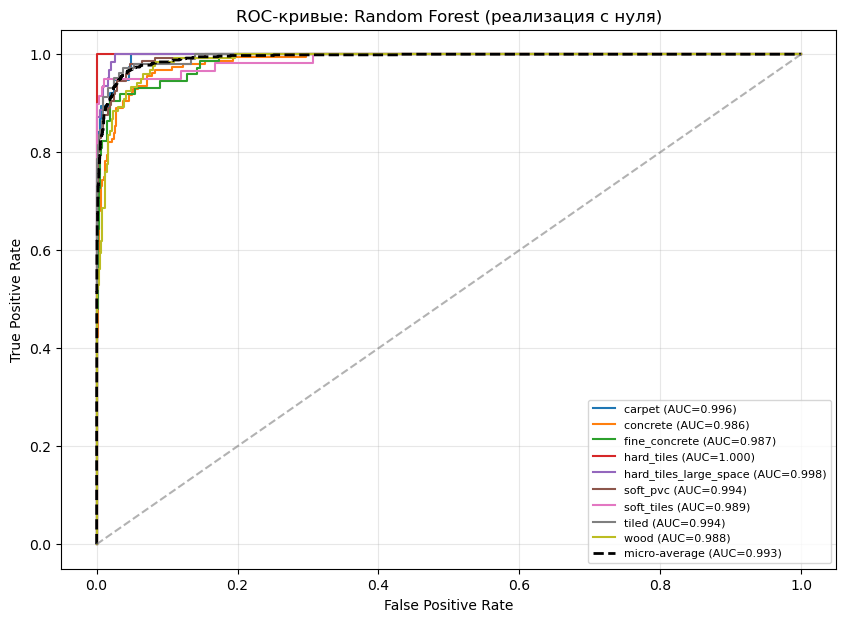

In [7]:
def binary_roc_curve(y_true_bin, y_score):
    order = np.argsort(-y_score)
    y = y_true_bin[order]

    P = np.sum(y == 1)
    N = np.sum(y == 0)

    if P == 0 or N == 0:
        return np.array([0.0, 1.0]), np.array([0.0, 1.0])

    tpr = [0.0]
    fpr = [0.0]

    tp = 0
    fp = 0

    for yi in y:
        if yi == 1:
            tp += 1
        else:
            fp += 1
        tpr.append(tp / P)
        fpr.append(fp / N)

    return np.array(fpr), np.array(tpr)


def auc_trapz(fpr, tpr):
    order = np.argsort(fpr)
    return np.trapz(tpr[order], fpr[order])


n_classes = len(classes)
y_valid_bin = np.zeros((len(y_valid), n_classes), dtype=int)
for i, yi in enumerate(y_valid):
    y_valid_bin[i, yi] = 1

fpr = {}
tpr = {}
roc_auc = {}

for c in range(n_classes):
    fpr[c], tpr[c] = binary_roc_curve(y_valid_bin[:, c], y_proba[:, c])
    roc_auc[c] = auc_trapz(fpr[c], tpr[c])

fpr_micro, tpr_micro = binary_roc_curve(y_valid_bin.ravel(), y_proba.ravel())
roc_auc_micro = auc_trapz(fpr_micro, tpr_micro)

plt.figure(figsize=(10, 7))
for c in range(n_classes):
    plt.plot(fpr[c], tpr[c], lw=1.5, label=f'{id_to_cls[c]} (AUC={roc_auc[c]:.3f})')

plt.plot(fpr_micro, tpr_micro, 'k--', lw=2, label=f'micro-average (AUC={roc_auc_micro:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.6)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые: Random Forest (реализация с нуля)')
plt.legend(loc='lower right', fontsize=8)
plt.grid(alpha=0.3)
plt.show()

## 7) Краткий вывод

- Random Forest реализован без `scikit-learn`.
- Деревья ансамбля несбалансированы по форме, глубина ветвей различается.
- Ограничение `max_depth` использовано как регуляризация против переобучения.
- Рассчитаны `accuracy`, `precision`, `recall`, `F1`, построены ROC-кривые OvR.